# House Prices EDA

Цель проекта — предсказать стоимость дома `SalePrice`.

Это задача регрессии.

Основная метрика Kaggle — ошибка на логарифме цены, поэтому дальше будем анализировать и `SalePrice`, и `log1p(SalePrice)`.
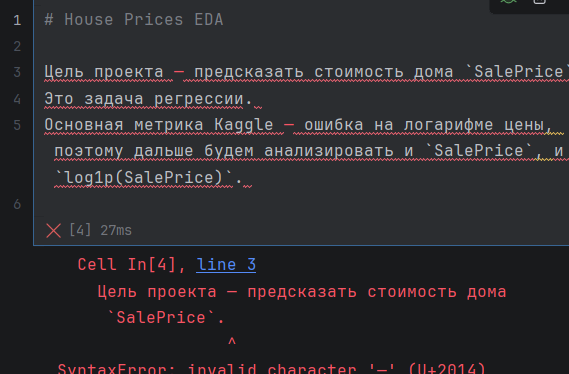

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/PythonProjects/HousePrices')

In [6]:
from configs.config import TARGET_COLUMN
from src.data import load_data


train, test, sample_submission = load_data()

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")
print(f"Target column: {TARGET_COLUMN}")

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)
Target column: SalePrice


In [7]:
display(train.head())
display(test.head())
display(sample_submission.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [8]:
print("Train columns:", train.shape[1])
print("Test columns:", test.shape[1])
print()

print(train.info())

Train columns: 81
Test columns: 80

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nul

In [9]:
train[TARGET_COLUMN].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

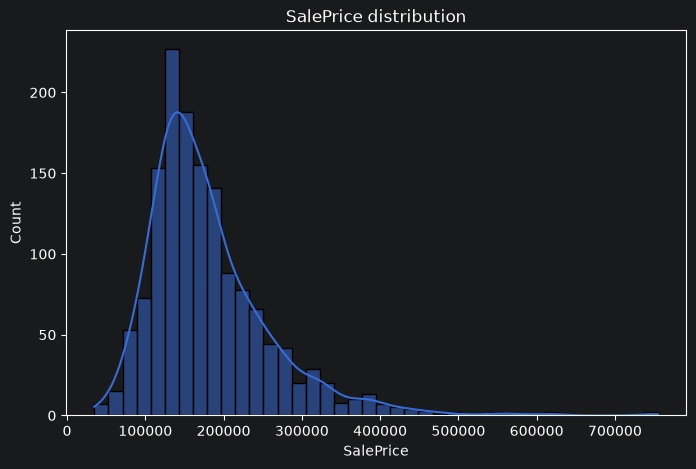

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(train[TARGET_COLUMN], bins=40, kde=True)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

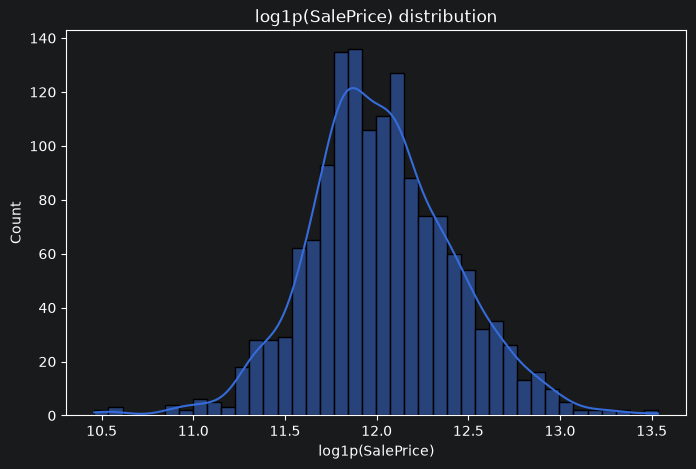

In [11]:
train["SalePriceLog"] = np.log1p(train[TARGET_COLUMN])

plt.figure(figsize=(8, 5))
sns.histplot(train["SalePriceLog"], bins=40, kde=True)
plt.title("log1p(SalePrice) distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

In [12]:
missing_train = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_train = missing_train[missing_train > 0]

missing_train

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageYrBlt       81
GarageFinish      81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64

In [13]:
missing_percent = (missing_train / len(train) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_train,
    "missing_percent": missing_percent,
})

missing_summary

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [17]:
numeric_features = train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = train.select_dtypes(include=["object", "str", "category"]).columns.tolist()

numeric_features = [
    col for col in numeric_features
    if col not in ["Id", TARGET_COLUMN, "SalePriceLog"]
]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 36
Categorical features: 43


In [19]:
#Корреляции с ценой
correlations = (
    train[numeric_features + [TARGET_COLUMN]]
    .corr()[TARGET_COLUMN]
    .sort_values(ascending=False)
)

correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

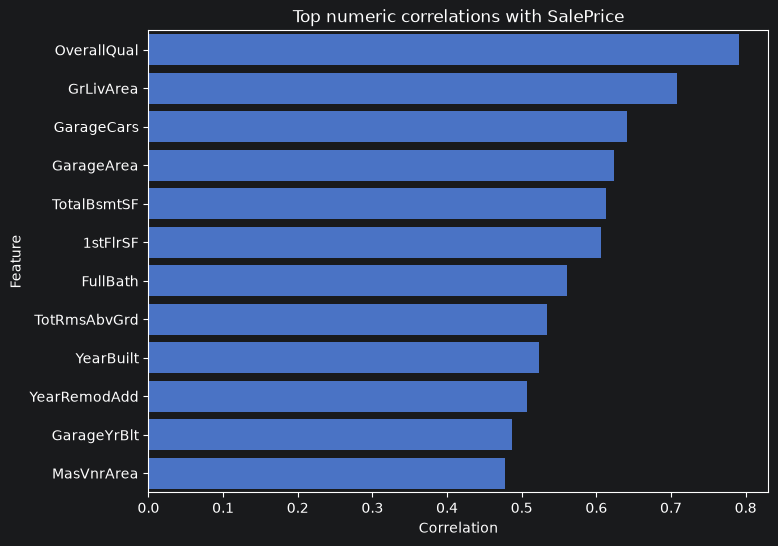

In [20]:
top_corr = correlations.drop(TARGET_COLUMN).head(12)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top numeric correlations with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

## Первые выводы EDA

На этом этапе мы уже проверили:

- размер train/test;
- распределение `SalePrice`;
- распределение `log1p(SalePrice)`;
- пропущенные значения;
- числовые и категориальные признаки;
- корреляции числовых признаков с ценой.

Дальше детальнее посмотрим на признаки, которые сильнее всего связаны с ценой дома.

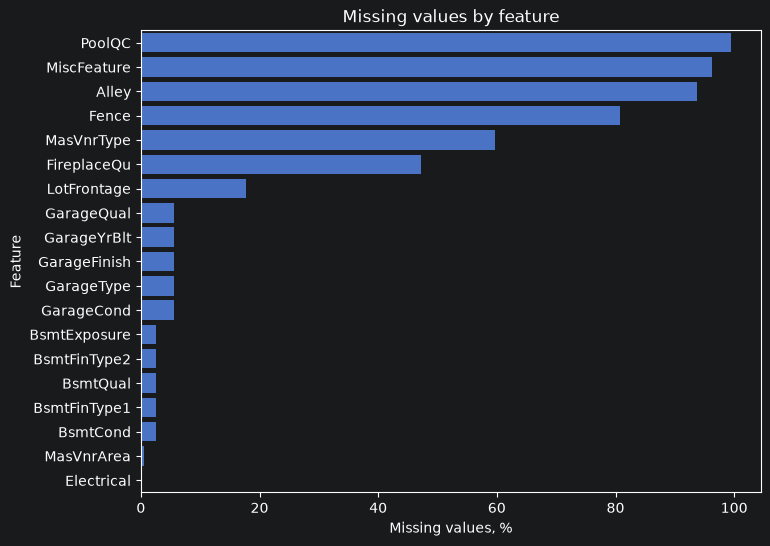

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=missing_summary["missing_percent"],
    y=missing_summary.index
)
plt.title("Missing values by feature")
plt.xlabel("Missing values, %")
plt.ylabel("Feature")
plt.show()

## Важные числовые признаки

По корреляции с `SalePrice` обычно выделяются:

- `OverallQual` — общее качество материалов и отделки;
- `GrLivArea` — жилая площадь над землёй;
- `GarageCars` — вместимость гаража;
- `GarageArea` — площадь гаража;
- `TotalBsmtSF` — площадь подвала;
- `1stFlrSF` — площадь первого этажа.

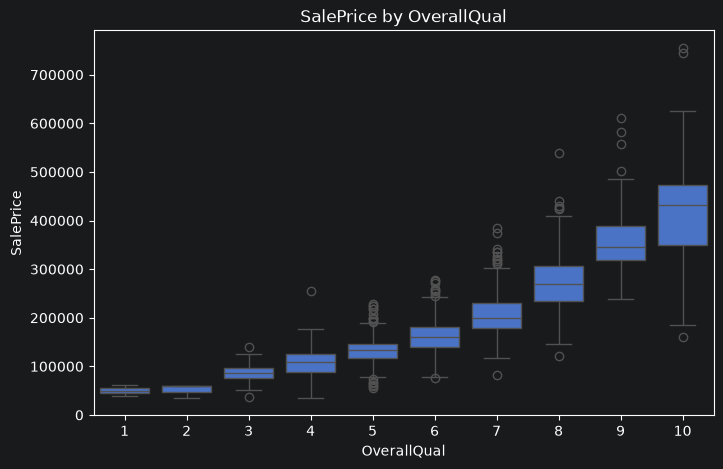

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x="OverallQual", y=TARGET_COLUMN)
plt.title("SalePrice by OverallQual")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

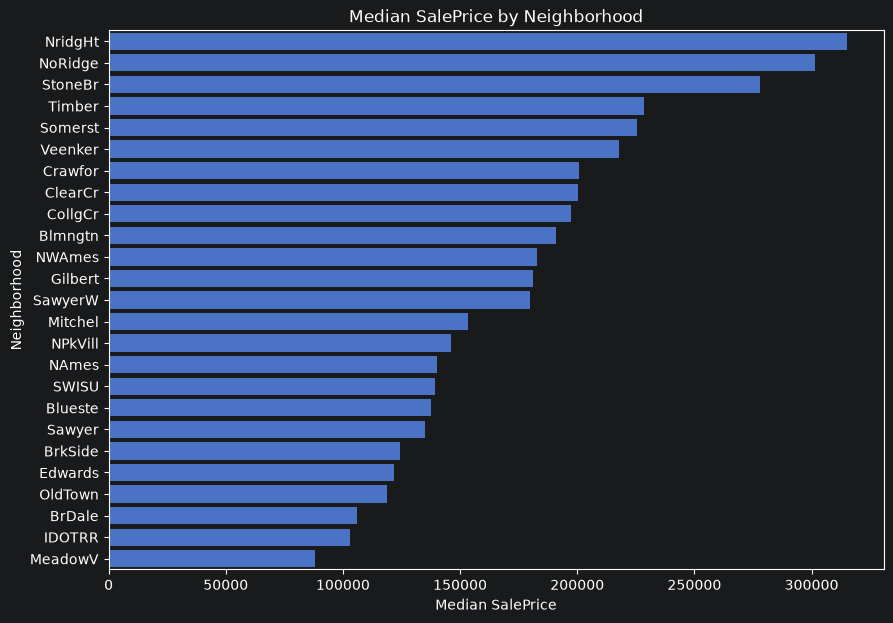

In [25]:
neighborhood_prices = (
    train.groupby("Neighborhood")[TARGET_COLUMN]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=neighborhood_prices.values, y=neighborhood_prices.index)
plt.title("Median SalePrice by Neighborhood")
plt.xlabel("Median SalePrice")
plt.ylabel("Neighborhood")
plt.show()

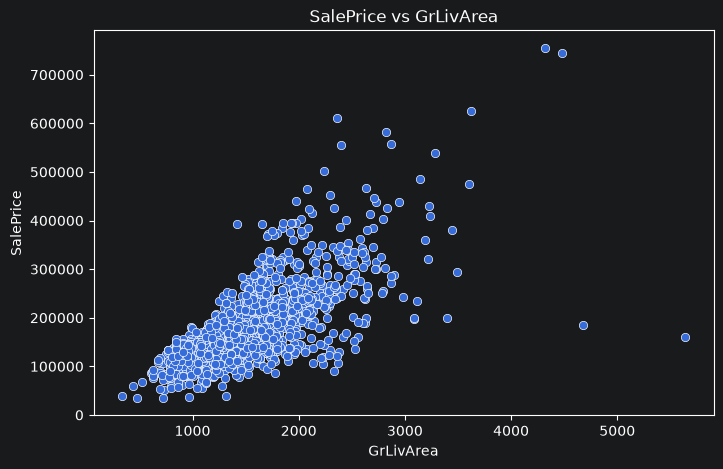

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x="GrLivArea", y=TARGET_COLUMN)
plt.title("SalePrice vs GrLivArea")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [24]:
outliers = train[
    (train["GrLivArea"] > 4000) &
    (train[TARGET_COLUMN] < 300000)
]

outliers[["Id", "GrLivArea", TARGET_COLUMN, "OverallQual"]]

,Id,GrLivArea,SalePrice,OverallQual
523,524,4676,184750,10
1298,1299,5642,160000,10


Удаляем два дома которые ломают модель своим качеством, большим размером и необоснованно низкой ценой.
они в таблице выше через одну. Создаем новую таблицу без них

In [26]:
outlier_ids = [524, 1299]

train_clean = train[~train["Id"].isin(outlier_ids)].copy()

print(f"Original train shape: {train.shape}")
print(f"Clean train shape: {train_clean.shape}")
print(f"Removed rows: {train.shape[0] - train_clean.shape[0]}")

Original train shape: (1460, 82)
Clean train shape: (1458, 82)
Removed rows: 2


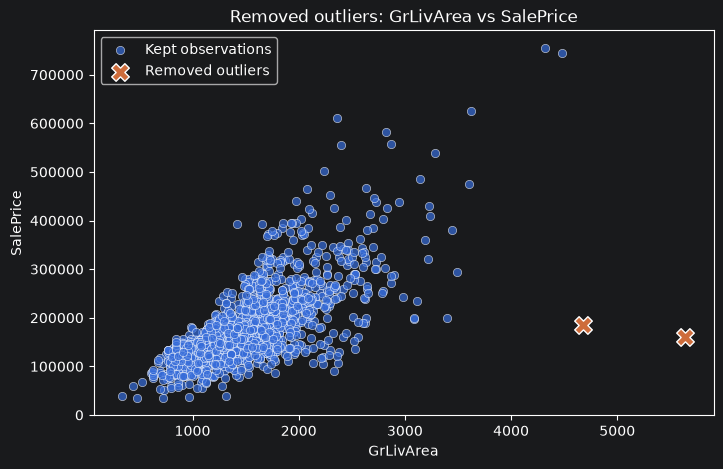

In [31]:
removed_outliers = train[train["Id"].isin(outlier_ids)]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_clean,
    x="GrLivArea",
    y=TARGET_COLUMN,
    alpha=0.7,
    label="Kept observations"
)

sns.scatterplot(
    data=removed_outliers,
    x="GrLivArea",
    y=TARGET_COLUMN,
    s=160,
    marker="X",
    label="Removed outliers"
)

plt.title("Removed outliers: GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

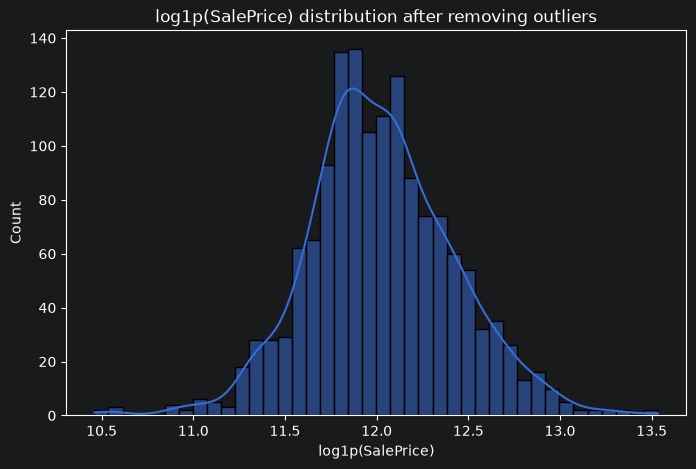

In [28]:
train_clean["SalePriceLog"] = np.log1p(train_clean[TARGET_COLUMN])

plt.figure(figsize=(8, 5))
sns.histplot(train_clean["SalePriceLog"], bins=40, kde=True)
plt.title("log1p(SalePrice) distribution after removing outliers")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

Удаление двух выбросов почти не меняет распределение `log1p(SalePrice)`, потому что удалено только 2 объекта из 1460, а их цены не являются экстремальными.

Эти объекты считаются выбросами не по целевой переменной, а по сочетанию признаков: очень большая `GrLivArea`, максимальный `OverallQual` и неожиданно низкая `SalePrice`.

## Baseline-модели

После EDA переходим к первому моделированию.

Так как задача - регрессия, будем предсказывать не `SalePrice`, а `log1p(SalePrice)`.
Метрика - RMSE на логарифме цены.

Сначала сравним:

- `DummyRegressor` - самый простой baseline, предсказывает среднее значение;
- `Ridge Regression` - первая нормальная линейная модель.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [35]:
X = train_clean.drop(columns=[TARGET_COLUMN, "SalePriceLog"])
y = np.log1p(train_clean[TARGET_COLUMN])

test_features = test.copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "Id"]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features + ["Id"]
]

print(f"X shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

X shape: (1458, 80)
Target shape: (1458,)
Numeric features: 36
Categorical features: 43


In [39]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

В препроцессинге выше происходит вот что
Для числовых признаков:

пропуски → медиана
масштабирование → StandardScaler

Для категориальных признаков:

пропуски → "None"
категории → OneHotEncoder

Например Neighborhood = "CollgCr" превращается в отдельный бинарный признак.

In [40]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
"Функция оценки модели"

def evaluate_model(model, X, y, model_name):
    """Evaluate a regression model using 5-fold cross-validation on log target."""
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    scores = -cross_val_score(
        pipeline,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )

    return {
        "model": model_name,
        "rmse_log_mean": scores.mean(),
        "rmse_log_std": scores.std(),
    }

Почему минус (scores = -cross_val_score)

cross_val_score в sklearn устроен так: чем больше score, тем лучше.

Но RMSE — наоборот:

меньше ошибка → лучше модель

Поэтому sklearn возвращает отрицательный RMSE:

neg_root_mean_squared_error

А мы делаем:

scores = -cross_val_score(...)

чтобы получить нормальные положительные значения ошибки.

In [41]:
"Dummy и Ridge"
baseline_results = []

baseline_results.append(
    evaluate_model(
        DummyRegressor(strategy="mean"),
        X,
        y,
        "DummyRegressor"
    )
)

baseline_results.append(
    evaluate_model(
        Ridge(alpha=10.0),
        X,
        y,
        "Ridge"
    )
)

baseline_results = pd.DataFrame(baseline_results)
baseline_results

,model,rmse_log_mean,rmse_log_std
0,DummyRegressor,0.399285,0.016812
1,Ridge,0.114835,0.008166


После Ridge добавим ещё несколько классических моделей:

- `Lasso` — линейная модель с отбором признаков;
- `ElasticNet` — комбинация Ridge и Lasso;
- `RandomForestRegressor` — ансамбль деревьев;
- `GradientBoostingRegressor` — бустинг на деревьях.

Все модели оцениваются одинаково: 5-fold CV, RMSE на `log1p(SalePrice)`.

In [42]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso

In [43]:
model_results = baseline_results.copy()

models_to_compare = [
    ("Lasso", Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
    ("ElasticNet", ElasticNet(alpha=0.0005, l1_ratio=0.7, max_iter=10000, random_state=42)),
    ("RandomForest", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
    ("GradientBoosting", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        random_state=42,
    )),
]

for model_name, model in models_to_compare:
    result = evaluate_model(model, X, y, model_name)
    model_results = pd.concat(
        [model_results, pd.DataFrame([result])],
        ignore_index=True,
    )

model_results.sort_values("rmse_log_mean")

,model,rmse_log_mean,rmse_log_std
2,Lasso,0.112824,0.006212
3,ElasticNet,0.113149,0.006280
1,Ridge,0.114835,0.008166
5,GradientBoosting,0.121498,0.007185
4,RandomForest,0.139201,0.009655
0,DummyRegressor,0.399285,0.016812


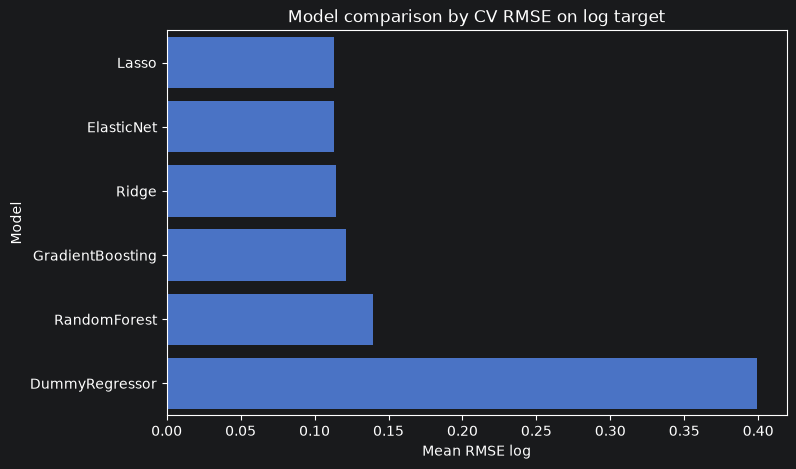

In [44]:
model_results_sorted = model_results.sort_values("rmse_log_mean")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_results_sorted,
    x="rmse_log_mean",
    y="model",
)

plt.title("Model comparison by CV RMSE on log target")
plt.xlabel("Mean RMSE log")
plt.ylabel("Model")
plt.show()

## Вывод по baseline-моделям

`DummyRegressor` показывает качество наивного прогноза и нужен только как нижняя граница.

`Ridge` уже сильно улучшает результат, значит признаки действительно хорошо объясняют цену дома.

Дальше будем улучшать качество за счёт feature engineering(создание новых признаков из уже существующих) и более сильных моделей.
Идея: модели проще работать с признаками, которые уже выражают понятный смысл:

- общая площадь дома;
- общее количество ванных комнат;
- возраст дома на момент продажи;
- возраст ремонта;
- наличие гаража, подвала, камина, бассейна;
- взаимодействие качества дома и площади.

In [45]:
def add_features(data):
    """Create additional features for the House Prices dataset."""
    data = data.copy()

    data["TotalSF"] = (
        data["TotalBsmtSF"].fillna(0)
        + data["1stFlrSF"].fillna(0)
        + data["2ndFlrSF"].fillna(0)
    )

    data["TotalBathrooms"] = (
        data["FullBath"].fillna(0)
        + 0.5 * data["HalfBath"].fillna(0)
        + data["BsmtFullBath"].fillna(0)
        + 0.5 * data["BsmtHalfBath"].fillna(0)
    )

    data["TotalPorchSF"] = (
        data["OpenPorchSF"].fillna(0)
        + data["EnclosedPorch"].fillna(0)
        + data["3SsnPorch"].fillna(0)
        + data["ScreenPorch"].fillna(0)
        + data["WoodDeckSF"].fillna(0)
    )

    data["HouseAge"] = data["YrSold"] - data["YearBuilt"]
    data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]
    data["GarageAge"] = data["YrSold"] - data["GarageYrBlt"]

    data["IsRemodeled"] = (data["YearRemodAdd"] != data["YearBuilt"]).astype(int)
    data["HasGarage"] = (data["GarageArea"].fillna(0) > 0).astype(int)
    data["HasBasement"] = (data["TotalBsmtSF"].fillna(0) > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"].fillna(0) > 0).astype(int)
    data["HasPool"] = (data["PoolArea"].fillna(0) > 0).astype(int)
    data["HasPorch"] = (data["TotalPorchSF"].fillna(0) > 0).astype(int)

    data["QualitySF"] = data["OverallQual"] * data["TotalSF"]

    return data

In [46]:
train_fe = add_features(train_clean)
test_fe = add_features(test)

new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "IsRemodeled",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "HasPorch",
    "QualitySF",
]

train_fe[new_features].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge,GarageAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,QualitySF
0,2566,3.5,61,5,5,5.0,0,1,1,0,0,1,17962
1,2524,2.5,298,31,31,31.0,0,1,1,1,0,1,15144
2,2706,3.5,42,7,6,7.0,1,1,1,1,0,1,18942
3,2473,2.0,307,91,36,8.0,1,1,1,1,0,1,17311
4,3343,3.5,276,8,8,8.0,0,1,1,1,0,1,26744


In [47]:
X_fe = train_fe.drop(columns=[TARGET_COLUMN, "SalePriceLog"])
y_fe = np.log1p(train_fe[TARGET_COLUMN])

numeric_features_fe = X_fe.select_dtypes(include=[np.number]).columns.tolist()
numeric_features_fe = [col for col in numeric_features_fe if col != "Id"]

categorical_features_fe = [
    col for col in X_fe.columns
    if col not in numeric_features_fe + ["Id"]
]

print(f"X_fe shape: {X_fe.shape}")
print(f"Target shape: {y_fe.shape}")
print(f"Numeric features: {len(numeric_features_fe)}")
print(f"Categorical features: {len(categorical_features_fe)}")

X_fe shape: (1458, 93)
Target shape: (1458,)
Numeric features: 49
Categorical features: 43


In [48]:
numeric_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, numeric_features_fe),
        ("cat", categorical_transformer_fe, categorical_features_fe),
    ]
)

In [49]:
def evaluate_model_fe(model, X, y, model_name):
    """Evaluate a regression model with feature engineering using 5-fold CV."""
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_fe),
            ("model", model),
        ]
    )

    scores = -cross_val_score(
        pipeline,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )

    return {
        "model": model_name,
        "rmse_log_mean": scores.mean(),
        "rmse_log_std": scores.std(),
    }

In [50]:
model_results_fe = []
"Проверяем модели после FE"
models_to_compare_fe = [
    ("Lasso_FE", Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
    ("ElasticNet_FE", ElasticNet(alpha=0.0005, l1_ratio=0.7, max_iter=10000, random_state=42)),
    ("Ridge_FE", Ridge(alpha=10.0)),
    ("RandomForest_FE", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
    ("GradientBoosting_FE", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        random_state=42,
    )),
]

for model_name, model in models_to_compare_fe:
    result = evaluate_model_fe(model, X_fe, y_fe, model_name)
    model_results_fe.append(result)

model_results_fe = pd.DataFrame(model_results_fe)
model_results_fe.sort_values("rmse_log_mean")

,model,rmse_log_mean,rmse_log_std
0,Lasso_FE,0.112641,0.006404
1,ElasticNet_FE,0.113064,0.006387
2,Ridge_FE,0.114973,0.008013
4,GradientBoosting_FE,0.121671,0.007447
3,RandomForest_FE,0.133820,0.008544


In [51]:
comparison_results = pd.concat(
    [
        model_results.assign(stage="Baseline"),
        model_results_fe.assign(stage="Feature Engineering"),
    ],
    ignore_index=True,
)

comparison_results.sort_values("rmse_log_mean")

,model,rmse_log_mean,rmse_log_std,stage
6,Lasso_FE,0.112641,0.006404,Feature Engineering
2,Lasso,0.112824,0.006212,Baseline
7,ElasticNet_FE,0.113064,0.006387,Feature Engineering
3,ElasticNet,0.113149,0.006280,Baseline
1,Ridge,0.114835,0.008166,Baseline
8,Ridge_FE,0.114973,0.008013,Feature Engineering
5,GradientBoosting,0.121498,0.007185,Baseline
10,GradientBoosting_FE,0.121671,0.007447,Feature Engineering
9,RandomForest_FE,0.133820,0.008544,Feature Engineering
4,RandomForest,0.139201,0.009655,Baseline


## Выводы после Feature Engineering

После добавления новых признаков лучший результат показала модель `Lasso_FE`.

Feature engineering дал небольшое улучшение для линейных моделей:

- `Lasso`: 0.112824
- `Lasso_FE`: 0.112641

Улучшение очень маленькое, поэтому новые признаки нельзя считать сильным прорывом.
Но они не ухудшили лучшую модель и заметно помогли `RandomForest`.

Дальше будем подбирать параметры для лучших линейных моделей.

In [52]:
from sklearn.model_selection import GridSearchCV

In [53]:
"tuning Lasso"
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", Lasso(max_iter=20000, random_state=42)),
    ]
)

lasso_param_grid = {
    "model__alpha": [0.0001, 0.0002, 0.0003, 0.0005, 0.0007, 0.001, 0.002]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)

lasso_grid.fit(X_fe, y_fe)

print("Best Lasso params:", lasso_grid.best_params_)
print("Best Lasso RMSE log:", -lasso_grid.best_score_)

Best Lasso params: {'model__alpha': 0.0005}
Best Lasso RMSE log: 0.11264137367610143


In [55]:
"сравнение tuned-моделей"
tuned_results = pd.DataFrame(
    [
        {
            "model": "Lasso_FE",
            "rmse_log_mean": model_results_fe.loc[
                model_results_fe["model"] == "Lasso_FE",
                "rmse_log_mean"
            ].iloc[0],
            "stage": "Before tuning",
        },
        {
            "model": "Tuned_Lasso_FE",
            "rmse_log_mean": -lasso_grid.best_score_,
            "stage": "After tuning",
        },
        {
            "model": "ElasticNet_FE",
            "rmse_log_mean": model_results_fe.loc[
                model_results_fe["model"] == "ElasticNet_FE",
                "rmse_log_mean"
            ].iloc[0],
            "stage": "Before tuning",
        },
        {
            "model": "Tuned_ElasticNet_FE",
            "rmse_log_mean": -elasticnet_grid.best_score_,
            "stage": "After tuning",
        },
    ]
)

tuned_results.sort_values("rmse_log_mean")

,model,rmse_log_mean,stage
0,Lasso_FE,0.112641,Before tuning
1,Tuned_Lasso_FE,0.112641,After tuning
3,Tuned_ElasticNet_FE,0.112664,After tuning
2,ElasticNet_FE,0.113064,Before tuning


In [54]:
"tuning ElasticNet"
elasticnet_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", ElasticNet(max_iter=20000, random_state=42)),
    ]
)

elasticnet_param_grid = {
    "model__alpha": [0.0001, 0.0002, 0.0003, 0.0005, 0.0007, 0.001, 0.002],
    "model__l1_ratio": [0.2, 0.5, 0.7, 0.9],
}

elasticnet_grid = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=elasticnet_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)

elasticnet_grid.fit(X_fe, y_fe)

print("Best ElasticNet params:", elasticnet_grid.best_params_)
print("Best ElasticNet RMSE log:", -elasticnet_grid.best_score_)

Best ElasticNet params: {'model__alpha': 0.0005, 'model__l1_ratio': 0.9}
Best ElasticNet RMSE log: 0.1126636559648343


Лучшей моделью на текущем этапе стала `Lasso_FE`.

Обучим её на всём очищенном train-наборе, сделаем предсказания для `test.csv`, переведём предсказания обратно из логарифма в обычные цены и сохраним файл для Kaggle.

## Optional checkpoint: first simple submission

Этот блок сохраняет первый submission на основе `Lasso_FE`.

Это не финальная модель.
Основной эксперимент продолжается ниже: boosting-модели, ensemble, DNN и финальный pipeline.

In [56]:
from configs.config import ID_COLUMN, SUBMISSIONS_DIR
"обучаем лучшую модель и предсказываем test"
best_model = lasso_grid.best_estimator_

test_predictions_log = best_model.predict(test_fe)
test_predictions = np.expm1(test_predictions_log)

test_predictions = np.maximum(test_predictions, 0)

submission_lasso_fe = pd.DataFrame({
    ID_COLUMN: test[ID_COLUMN],
    TARGET_COLUMN: test_predictions,
})

display(submission_lasso_fe.head())
display(submission_lasso_fe.describe())

,Id,SalePrice
0,1461,119897.230139
1,1462,149649.261926
2,1463,176611.244133
3,1464,201969.635895
4,1465,188970.899961


,Id,SalePrice
count,1459.000000,1.459000e+03
mean,2190.000000,1.792781e+05
std,421.321334,8.798326e+04
min,1461.000000,4.309689e+04
25%,1825.500000,1.261544e+05
50%,2190.000000,1.570541e+05
75%,2554.500000,2.104490e+05
max,2919.000000,1.742046e+06


In [57]:
print(f"Submission shape: {submission_lasso_fe.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

print("Missing predictions:", submission_lasso_fe[TARGET_COLUMN].isna().sum())
print("Negative predictions:", (submission_lasso_fe[TARGET_COLUMN] < 0).sum())

print("IDs match sample submission:")
print(submission_lasso_fe[ID_COLUMN].equals(sample_submission[ID_COLUMN]))

Submission shape: (1459, 2)
Sample submission shape: (1459, 2)
Missing predictions: 0
Negative predictions: 0
IDs match sample submission:
True


In [58]:
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
"Соранение"
submission_path = SUBMISSIONS_DIR / "lasso_fe_submission.csv"

submission_lasso_fe.to_csv(submission_path, index=False)

print(f"Saved submission to: {submission_path}")

Saved submission to: C:\PythonProjects\HousePrices\submissions\lasso_fe_submission.csv


## Boosting Models

После baseline-моделей и feature engineering проверим более сильные модели для табличных данных:

- LightGBM
- XGBoost
- CatBoost

Сравнение будет честным: используем те же `X_fe`, `y_fe`, тот же `cv` и ту же метрику RMSE на `log1p(SalePrice)`.

In [61]:
try:
    from lightgbm import LGBMRegressor
    print("LightGBM: OK")
except ModuleNotFoundError:
    print("LightGBM is not installed")

try:
    from xgboost import XGBRegressor
    print("XGBoost: OK")
except ModuleNotFoundError:
    print("XGBoost is not installed")

try:
    from catboost import CatBoostRegressor
    print("CatBoost: OK")
except ModuleNotFoundError:
    print("CatBoost is not installed")

LightGBM: OK
XGBoost: OK
CatBoost: OK


## Boosting model evaluation

Теперь проверим три более сильные модели:

- `LightGBM`
- `XGBoost`
- `CatBoost`

Пока используем те же признаки `X_fe`, ту же цель `y_fe`, тот же `cv` и ту же метрику.

Цель — проверить, смогут ли бустинги побить текущий лучший результат:

`Lasso_FE`: около `0.112641`.

In [67]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [68]:
boosting_models = [
    (
        "LightGBM_FE",
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        ),
    ),
    (
        "XGBoost_FE",
        XGBRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "CatBoost_FE",
        CatBoostRegressor(
            iterations=1000,
            learning_rate=0.03,
            depth=5,
            loss_function="RMSE",
            random_state=42,
            verbose=0,
            allow_writing_files=False,
        ),
    ),
]

In [69]:
boosting_results = []

for model_name, model in boosting_models:
    print(f"Evaluating {model_name}...")
    result = evaluate_model_fe(model, X_fe, y_fe, model_name)
    boosting_results.append(result)

boosting_results = pd.DataFrame(boosting_results)

boosting_results.sort_values("rmse_log_mean")

Evaluating LightGBM_FE...
Evaluating XGBoost_FE...
Evaluating CatBoost_FE...


,model,rmse_log_mean,rmse_log_std
2,CatBoost_FE,0.113077,0.007296
1,XGBoost_FE,0.115225,0.005817
0,LightGBM_FE,0.123803,0.007862


In [71]:
all_model_results = pd.concat(
    [
        model_results.assign(stage="Baseline"),
        model_results_fe.assign(stage="Feature Engineering"),
        boosting_results.assign(stage="Boosting"),
    ],
    ignore_index=True,
)

all_model_results_sorted = (
    all_model_results
    .sort_values("rmse_log_mean")
    .reset_index(drop=True)
)

display(all_model_results_sorted)

,model,rmse_log_mean,rmse_log_std,stage
0,Lasso_FE,0.112641,0.006404,Feature Engineering
1,Lasso,0.112824,0.006212,Baseline
2,ElasticNet_FE,0.113064,0.006387,Feature Engineering
3,CatBoost_FE,0.113077,0.007296,Boosting
4,ElasticNet,0.113149,0.006280,Baseline
5,Ridge,0.114835,0.008166,Baseline
6,Ridge_FE,0.114973,0.008013,Feature Engineering
7,XGBoost_FE,0.115225,0.005817,Boosting
8,GradientBoosting,0.121498,0.007185,Baseline
9,GradientBoosting_FE,0.121671,0.007447,Feature Engineering


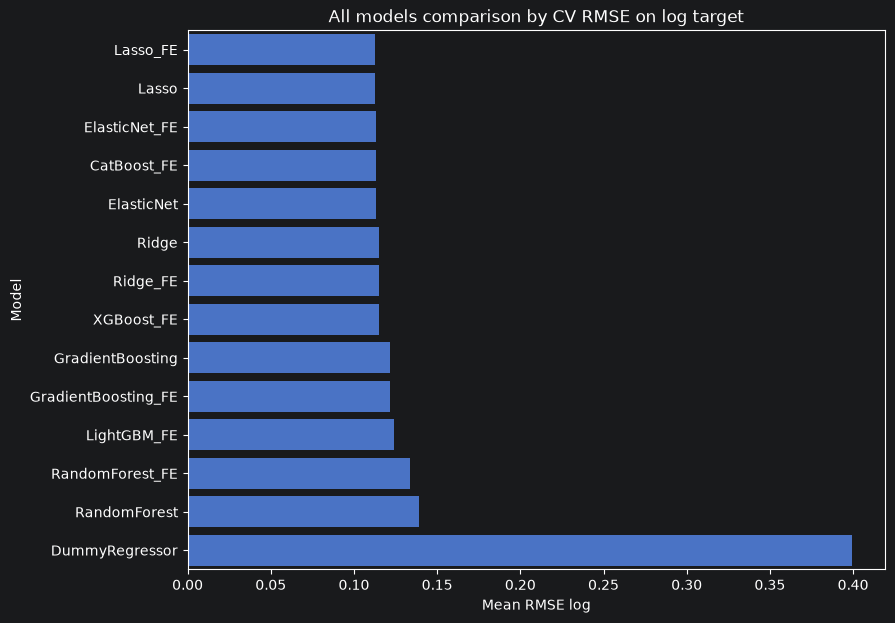

In [72]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=all_model_results_sorted,
    x="rmse_log_mean",
    y="model",
)

plt.title("All models comparison by CV RMSE on log target")
plt.xlabel("Mean RMSE log")
plt.ylabel("Model")
plt.show()

Сложные модели не выйграли. Очень близко к наилучшему но недостаточно

## Ensemble / Averaging

После сравнения отдельных моделей проверим простые ансамбли.

Идея ансамбля: объединить несколько моделей и усреднить их предсказания.

Проверим:

- ансамбль линейных моделей;
- ансамбль `Lasso` + `CatBoost`;
- смешанный ансамбль из линейных моделей и бустингов.

In [75]:
from sklearn.ensemble import VotingRegressor

In [76]:
def evaluate_estimator(estimator, X, y, model_name):
    "функция оценки готовых estimator/pipeline"
    """Evaluate a full sklearn estimator or pipeline using 5-fold CV."""
    scores = -cross_val_score(
        estimator,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,
    )

    return {
        "model": model_name,
        "rmse_log_mean": scores.mean(),
        "rmse_log_std": scores.std(),
    }

In [79]:
"создаём pipelines для ансамблей"
lasso_best_pipeline = lasso_grid.best_estimator_
elasticnet_best_pipeline = elasticnet_grid.best_estimator_

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", Ridge(alpha=10.0)),
    ]
)

catboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", CatBoostRegressor(
            iterations=800,
            learning_rate=0.03,
            depth=5,
            loss_function="RMSE",
            random_state=42,
            verbose=0,
            allow_writing_files=False,
            thread_count=-1,
        )),
    ]
)

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", XGBRegressor(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

In [80]:
"тестируем ensemble-модели"
ensemble_models = [
    (
        "Linear_Ensemble_FE",
        VotingRegressor(
            estimators=[
                ("lasso", lasso_best_pipeline),
                ("elasticnet", elasticnet_best_pipeline),
                ("ridge", ridge_pipeline),
            ]
        ),
    ),
    (
        "Lasso_CatBoost_Ensemble_FE",
        VotingRegressor(
            estimators=[
                ("lasso", lasso_best_pipeline),
                ("catboost", catboost_pipeline),
            ],
            weights=[0.6, 0.4],
        ),
    ),
    (
        "Mixed_Ensemble_FE",
        VotingRegressor(
            estimators=[
                ("lasso", lasso_best_pipeline),
                ("elasticnet", elasticnet_best_pipeline),
                ("catboost", catboost_pipeline),
                ("xgboost", xgboost_pipeline),
            ],
            weights=[0.4, 0.25, 0.25, 0.10],
        ),
    ),
]

ensemble_results = []

for model_name, model in ensemble_models:
    print(f"Evaluating {model_name}...")
    result = evaluate_estimator(model, X_fe, y_fe, model_name)
    ensemble_results.append(result)

ensemble_results = pd.DataFrame(ensemble_results)

display(ensemble_results.sort_values("rmse_log_mean"))

Evaluating Linear_Ensemble_FE...
Evaluating Lasso_CatBoost_Ensemble_FE...
Evaluating Mixed_Ensemble_FE...


,model,rmse_log_mean,rmse_log_std
1,Lasso_CatBoost_Ensemble_FE,0.109384,0.006365
2,Mixed_Ensemble_FE,0.109484,0.006188
0,Linear_Ensemble_FE,0.112981,0.006876


In [81]:
all_model_results = pd.concat(
    [
        model_results.assign(stage="Baseline"),
        model_results_fe.assign(stage="Feature Engineering"),
        boosting_results.assign(stage="Boosting"),
        ensemble_results.assign(stage="Ensemble"),
    ],
    ignore_index=True,
)

all_model_results_sorted = (
    all_model_results
    .sort_values("rmse_log_mean")
    .reset_index(drop=True)
)

display(all_model_results_sorted)

,model,rmse_log_mean,rmse_log_std,stage
0,Lasso_CatBoost_Ensemble_FE,0.109384,0.006365,Ensemble
1,Mixed_Ensemble_FE,0.109484,0.006188,Ensemble
2,Lasso_FE,0.112641,0.006404,Feature Engineering
3,Lasso,0.112824,0.006212,Baseline
4,Linear_Ensemble_FE,0.112981,0.006876,Ensemble
5,ElasticNet_FE,0.113064,0.006387,Feature Engineering
6,CatBoost_FE,0.113077,0.007296,Boosting
7,ElasticNet,0.113149,0.006280,Baseline
8,Ridge,0.114835,0.008166,Baseline
9,Ridge_FE,0.114973,0.008013,Feature Engineering


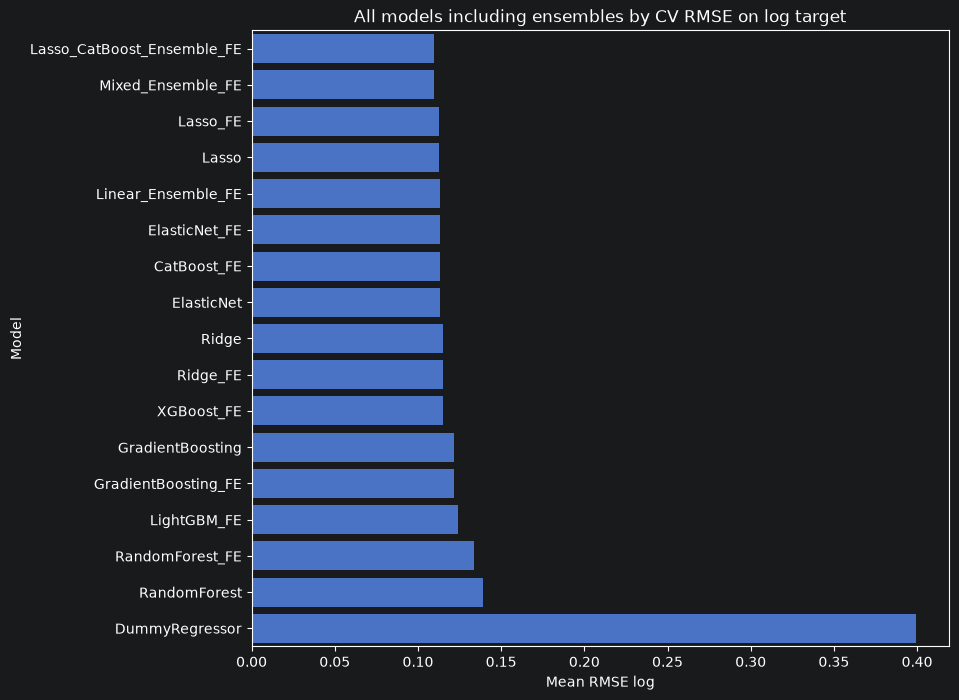

In [82]:
plt.figure(figsize=(9, 8))

sns.barplot(
    data=all_model_results_sorted,
    x="rmse_log_mean",
    y="model",
)

plt.title("All models including ensembles by CV RMSE on log target")
plt.xlabel("Mean RMSE log")
plt.ylabel("Model")
plt.show()

## Ensemble Weight Tuning

Лучший результат сейчас показал ансамбль `Lasso + CatBoost`.

Подберём оптимальные веса для усреднения предсказаний:

- больший вес `Lasso`, если линейная модель стабильнее;
- больший вес `CatBoost`, если бустинг добавляет полезный нелинейный сигнал.

Для этого получим out-of-fold предсказания обеих моделей и проверим разные веса.

In [83]:
from sklearn.model_selection import cross_val_predict

In [84]:
print("Creating OOF predictions for Lasso...")

lasso_oof_preds = cross_val_predict(
    lasso_best_pipeline,
    X_fe,
    y_fe,
    cv=cv,
    n_jobs=-1,
)

print("Creating OOF predictions for CatBoost...")

catboost_oof_preds = cross_val_predict(
    catboost_pipeline,
    X_fe,
    y_fe,
    cv=cv,
    n_jobs=1,
)

print("Done")

Creating OOF predictions for Lasso...
Creating OOF predictions for CatBoost...
Done


Что такое OOF

OOF = out-of-fold predictions.

То есть для каждой строки train модель делает предсказание так, будто эта строка была “новой” и не участвовала в обучении конкретного fold.

Это честный способ проверять ensemble на train.

In [85]:
"Подбор весов"
weight_results = []

for lasso_weight in np.arange(0.1, 1.0, 0.05):
    catboost_weight = 1 - lasso_weight

    ensemble_oof_preds = (
        lasso_weight * lasso_oof_preds
        + catboost_weight * catboost_oof_preds
    )

    rmse_log = np.sqrt(mean_squared_error(y_fe, ensemble_oof_preds))

    weight_results.append({
        "lasso_weight": lasso_weight,
        "catboost_weight": catboost_weight,
        "rmse_log": rmse_log,
    })

weight_results = pd.DataFrame(weight_results)

display(
    weight_results
    .sort_values("rmse_log")
    .reset_index(drop=True)
)

,lasso_weight,catboost_weight,rmse_log
0,0.55,0.45,0.109515
1,0.50,0.50,0.109535
2,0.60,0.40,0.109573
3,0.45,0.55,0.109635
4,0.65,0.35,0.109710
5,0.40,0.60,0.109813
6,0.70,0.30,0.109925
7,0.35,0.65,0.110069
8,0.75,0.25,0.110218
9,0.30,0.70,0.110403


In [86]:
best_weight_row = weight_results.sort_values("rmse_log").iloc[0]

best_lasso_weight = best_weight_row["lasso_weight"]
best_catboost_weight = best_weight_row["catboost_weight"]
best_weighted_rmse = best_weight_row["rmse_log"]

print(f"Best Lasso weight: {best_lasso_weight:.2f}")
print(f"Best CatBoost weight: {best_catboost_weight:.2f}")
print(f"Best weighted ensemble RMSE log: {best_weighted_rmse:.6f}")

Best Lasso weight: 0.55
Best CatBoost weight: 0.45
Best weighted ensemble RMSE log: 0.109515


## Вывод по подбору весов ensemble

Лучший вес для ансамбля `Lasso + CatBoost` оказался примерно:

- `Lasso`: 0.55
- `CatBoost`: 0.45

Это очень близко к исходному варианту `0.6 / 0.4`, который уже показал лучший результат среди всех моделей.

Итог: ансамбль `Lasso + CatBoost` остаётся лучшей моделью на текущем этапе.

## DNN / Neural Network Experiment

Проверим нейросетевую модель на тех же данных.

Используем `MLPRegressor` из `scikit-learn`.

Это полносвязная нейросеть, которая получает обработанные признаки дома и предсказывает `log1p(SalePrice)`.

Сравниваем честно:

- те же `X_fe`, `y_fe`;
- тот же preprocessing;
- тот же 5-fold CV;
- та же метрика RMSE log.

In [87]:
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor

import warnings

In [88]:
def evaluate_neural_network(model, X, y, model_name):
    """Evaluate a neural network model using 5-fold CV."""
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_fe),
            ("model", model),
        ]
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        scores = -cross_val_score(
            pipeline,
            X,
            y,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=1,
        )

    return {
        "model": model_name,
        "rmse_log_mean": scores.mean(),
        "rmse_log_std": scores.std(),
    }

In [89]:
dnn_models = [
    (
        "MLP_64_32_FE",
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=32,
            learning_rate_init=0.001,
            max_iter=700,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42,
        ),
    ),
    (
        "MLP_128_64_FE",
        MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=32,
            learning_rate_init=0.001,
            max_iter=700,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42,
        ),
    ),
    (
        "MLP_128_64_32_FE",
        MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            solver="adam",
            alpha=0.003,
            batch_size=32,
            learning_rate_init=0.001,
            max_iter=700,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42,
        ),
    ),
]

In [90]:
dnn_results = []

for model_name, model in dnn_models:
    print(f"Evaluating {model_name}...")
    result = evaluate_neural_network(model, X_fe, y_fe, model_name)
    dnn_results.append(result)

dnn_results = pd.DataFrame(dnn_results)

display(dnn_results.sort_values("rmse_log_mean"))

Evaluating MLP_64_32_FE...
Evaluating MLP_128_64_FE...
Evaluating MLP_128_64_32_FE...


,model,rmse_log_mean,rmse_log_std
1,MLP_128_64_FE,0.207105,0.035582
2,MLP_128_64_32_FE,0.220470,0.079309
0,MLP_64_32_FE,0.252971,0.135473


In [91]:
all_model_results = pd.concat(
    [
        model_results.assign(stage="Baseline"),
        model_results_fe.assign(stage="Feature Engineering"),
        boosting_results.assign(stage="Boosting"),
        ensemble_results.assign(stage="Ensemble"),
        dnn_results.assign(stage="DNN"),
    ],
    ignore_index=True,
)

all_model_results_sorted = (
    all_model_results
    .sort_values("rmse_log_mean")
    .reset_index(drop=True)
)

display(all_model_results_sorted)

,model,rmse_log_mean,rmse_log_std,stage
0,Lasso_CatBoost_Ensemble_FE,0.109384,0.006365,Ensemble
1,Mixed_Ensemble_FE,0.109484,0.006188,Ensemble
2,Lasso_FE,0.112641,0.006404,Feature Engineering
3,Lasso,0.112824,0.006212,Baseline
4,Linear_Ensemble_FE,0.112981,0.006876,Ensemble
5,ElasticNet_FE,0.113064,0.006387,Feature Engineering
6,CatBoost_FE,0.113077,0.007296,Boosting
7,ElasticNet,0.113149,0.006280,Baseline
8,Ridge,0.114835,0.008166,Baseline
9,Ridge_FE,0.114973,0.008013,Feature Engineering


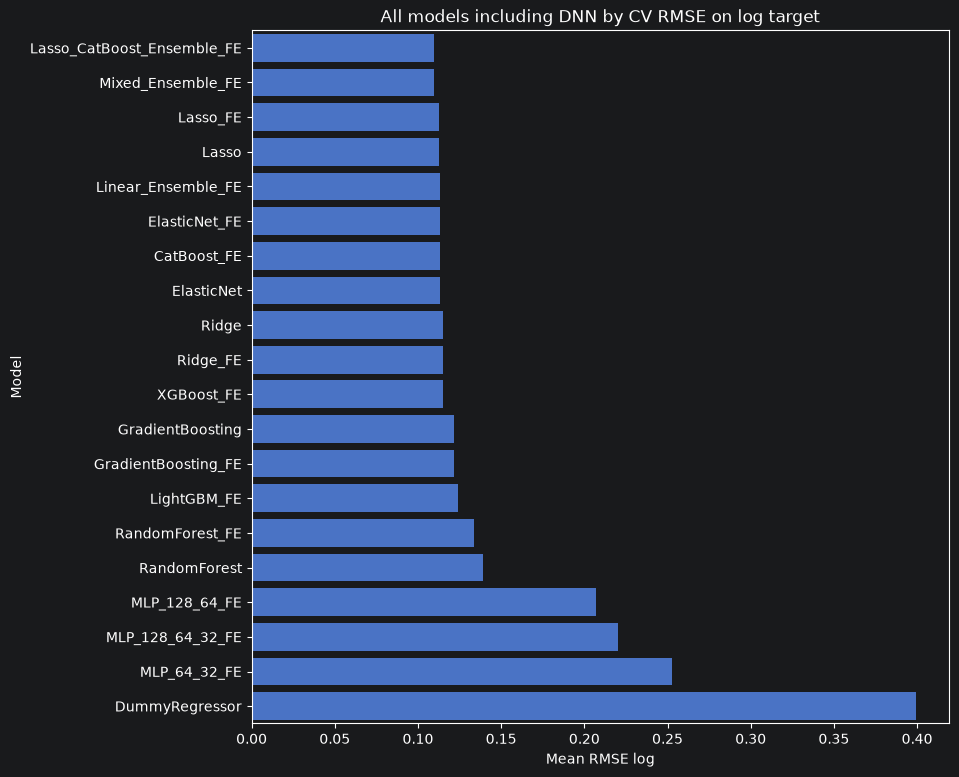

In [92]:
plt.figure(figsize=(9, 9))

sns.barplot(
    data=all_model_results_sorted,
    x="rmse_log_mean",
    y="model",
)

plt.title("All models including DNN by CV RMSE on log target")
plt.xlabel("Mean RMSE log")
plt.ylabel("Model")
plt.show()

## DNN experiment conclusion

Нейросетевые модели `MLPRegressor` были протестированы на тех же данных, что и остальные модели.

Результаты DNN оказались заметно хуже ансамбля `Lasso + CatBoost`.

Итог: DNN не используется как финальная модель, но эксперимент сохранён для полноты сравнения.

In [93]:
from configs.config import RESULTS_DIR

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_results_path = RESULTS_DIR / "all_model_results.csv"

all_model_results_sorted.to_csv(all_results_path, index=False)

print(f"Saved all model results to: {all_results_path}")

Saved all model results to: C:\PythonProjects\HousePrices\results\all_model_results.csv


## Final model selection

Финальной моделью выбираем ансамбль:

`Lasso + CatBoost`

Причина:

- лучший CV RMSE log среди всех протестированных моделей;
- Lasso хорошо ловит линейные зависимости;
- CatBoost добавляет нелинейные зависимости;
- усреднение предсказаний уменьшило ошибку.

Финальные веса:

- `Lasso`: 0.6
- `CatBoost`: 0.4

CV RMSE log:

`0.109384`

In [98]:
final_model = VotingRegressor(
    estimators=[
        ("lasso", lasso_best_pipeline),
        ("catboost", catboost_pipeline),
    ],
    weights=[0.6, 0.4],
)

final_model.fit(X_fe, y_fe)

print("Final ensemble model fitted.")

Final ensemble model fitted.


In [95]:
from configs.config import ID_COLUMN, SUBMISSIONS_DIR

test_predictions_log = final_model.predict(test_fe)
test_predictions = np.expm1(test_predictions_log)

test_predictions = np.maximum(test_predictions, 0)

final_submission = pd.DataFrame({
    ID_COLUMN: test[ID_COLUMN],
    TARGET_COLUMN: test_predictions,
})

display(final_submission.head())
display(final_submission.describe())

,Id,SalePrice
0,1461,121657.963158
1,1462,154008.492373
2,1463,178584.662255
3,1464,199448.725562
4,1465,184480.775540


,Id,SalePrice
count,1459.000000,1.459000e+03
mean,2190.000000,1.788154e+05
std,421.321334,8.182738e+04
min,1461.000000,4.310216e+04
25%,1825.500000,1.266570e+05
50%,2190.000000,1.565578e+05
75%,2554.500000,2.096447e+05
max,2919.000000,1.185751e+06


In [96]:
print(f"Final submission shape: {final_submission.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

print("Missing predictions:", final_submission[TARGET_COLUMN].isna().sum())
print("Negative predictions:", (final_submission[TARGET_COLUMN] < 0).sum())

print("IDs match sample submission:")
print(final_submission[ID_COLUMN].equals(sample_submission[ID_COLUMN]))

Final submission shape: (1459, 2)
Sample submission shape: (1459, 2)
Missing predictions: 0
Negative predictions: 0
IDs match sample submission:
True


In [97]:
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

final_submission_path = SUBMISSIONS_DIR / "final_lasso_catboost_ensemble_submission.csv"

final_submission.to_csv(final_submission_path, index=False)

print(f"Saved final submission to: {final_submission_path}")

Saved final submission to: C:\PythonProjects\HousePrices\submissions\final_lasso_catboost_ensemble_submission.csv
